# Project Notebook:
Names: Rylan Cottone, Kaleb Aklilu, Haocheng Zhang

Due: 28 April 2025

## Objective:
The objective of this project is to be able to use a DMM and resistive strips on a sphere (acting as the experimental space) to determine how resistance changes as the number of parallel paths increases. Using this, we can also calculate what the resistance provided by a single strip is

## Apparatus:
<img src="images/apparatus.jpg" width="500">

## Procedure:
1. Obtain a ball roughly $ 28 \pm 0.4 cm $ in diameter
2. Start by adding a single resistive strip of length $ 14 \pm 0.2 cm $ and width $ 1.4 \pm 0.2 cm $ such that it wraps halfway around the ball
3. Use two pins to hold the strip down and prevent movement during the experiment
4. Connect the ends of a digital multimeter (DMM) to each pin, ensuring the DMM is set to measure resistance
5. Measure the resistance value from the strip
6. Repeat Steps 2-5 while continuously increasing the number of strips (ensure each strip has copper tape to ensure contact) until the ball is covered

## Analysis:

In [103]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.optimize as opt
from matplotlib.patches import Patch

In [37]:
data = pd.read_csv("data/resistance_data.csv")
data

,Paths,Resistance (kΩ),dResistance (kΩ)
0,1,67.50,0.8750
1,2,33.15,0.3515
2,3,23.87,0.2587
3,4,17.76,0.1976
4,5,13.34,0.1534
5,6,10.84,0.1284
6,7,9.54,0.1154
7,8,8.54,0.1054
8,9,7.79,0.0979
9,10,6.91,0.0891


We know that, in a parallel circuit, the relation between equivalent resistance and individual resistors is $ \frac{1}{R_{eq}} = \frac{1}{R_1} + \frac{1}{R_2} + ... + \frac{1}{R_n} $

Given that all resistive strips *should* have the same level of resistance (due to being identical material and dimensions), we can simplify this formula to $ \frac{1}{R_{eq}} = \frac{n}{R} $, where $ R $ is the resistance provided by one strip

Using the above data, we seek to determine if this simplified formula holds true. To do that, we can linearize the data by setting $ y = R_{eq} $, $ x = \frac{1}{n} $, $ m = R $, and $ b = 0 $, using the inverse formula $ R_{eq} = \frac{R}{n} $

Start by creating a column for the inverse of the paths:

In [41]:
data["invPaths"] = 1 / data["Paths"]
data

,Paths,Resistance (kΩ),dResistance (kΩ),invPaths
0,1,67.50,0.8750,1.000000
1,2,33.15,0.3515,0.500000
2,3,23.87,0.2587,0.333333
3,4,17.76,0.1976,0.250000
4,5,13.34,0.1534,0.200000
5,6,10.84,0.1284,0.166667
6,7,9.54,0.1154,0.142857
7,8,8.54,0.1054,0.125000
8,9,7.79,0.0979,0.111111
9,10,6.91,0.0891,0.100000


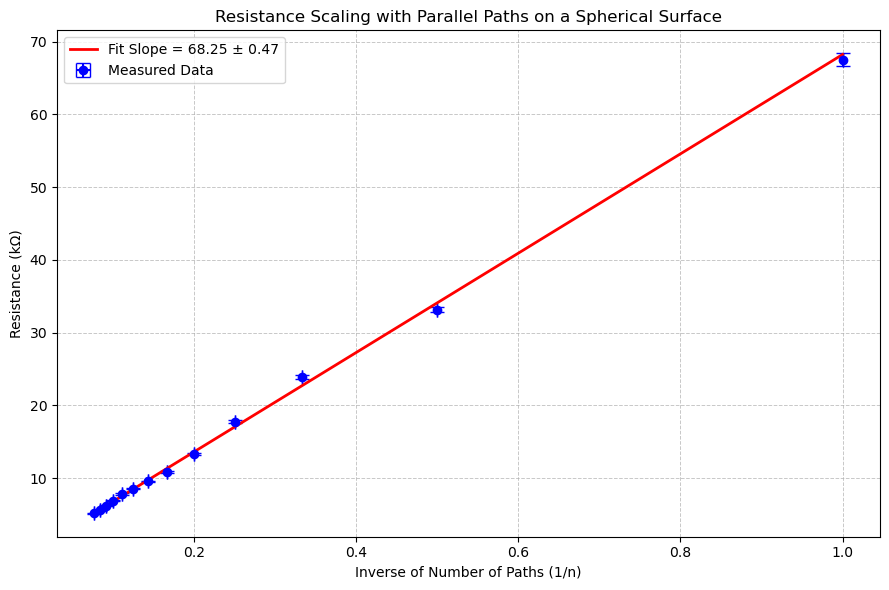

Slope (R): 68.25 ± 0.47 kΩ
Intercept (b): -0.04 ± 0.06 kΩ


In [170]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.optimize as opt

# Your data columns
x = data["invPaths"]
y = data["Resistance (kΩ)"]
yerr = data["dResistance (kΩ)"]
plt.figure(figsize=(9,6))
# Error bar plot
plt.errorbar(x, y, yerr=yerr, xerr=0, fmt="o", markersize=6, capsize=5, label="Measured Data", ecolor="b", c="b")


# Define linear model
def my_linear_model(x, A, B):
    return A * x + B

# Fit the data
fit_param, fit_cov = opt.curve_fit(
    my_linear_model, x, y,
    sigma=yerr, absolute_sigma=True
)

fitA, fitB = fit_param
fitdA = np.sqrt(fit_cov[0, 0])
fitdB = np.sqrt(fit_cov[1, 1])

# Plot the fit
x_fit = np.linspace(min(x), max(x), 100)
plt.plot(x_fit, my_linear_model(x_fit, fitA, fitB), '-', label=f"Fit Slope = {fitA:.2f} ± {fitdA:.2f}", c='r', linewidth=2)

# Labels and title
plt.xlabel("Inverse of Number of Paths (1/n)")
plt.ylabel("Resistance (kΩ)")
plt.title("Resistance Scaling with Parallel Paths on a Spherical Surface")

# Grid, legend, and layout improvements
plt.grid(True, which="both", linestyle="--", linewidth=0.7, alpha=0.7)
plt.legend()
plt.tight_layout()

# Show plot
plt.show()


# Optional: Print fit parameters
print(f"Slope (R): {fitA:.2f} ± {fitdA:.2f} kΩ")
print(f"Intercept (b): {fitB:.2f} ± {fitdB:.2f} kΩ")


Looking at the graph we received, we find that we do indeed get a very linear graph. The line goes through the uncertainty interval for every single point with no significant outliers. We also note that the expected value of $ b $ is met, seeing as $ -0.04 \pm 0.06 $ includes the expected $ b = 0 $. As such, we can conclude that the relationship predicted is matched in the experiment, wherein we get the relationship $ R_{eq} = \frac{68.3}{n} - 0.04 $, where $ n $ is the number of paths and $ R_{eq} $ is the equivalent resistance

Beyond simply verifying that a parallel circuit splits the resistance reciprocally, we are also able to determine from the data that the resistance of a single strip of the paper (of the aforementioned dimensions) is $ 68.3 \pm 0.5 kΩ $

We can also verify this data by looking at the opposite approach, where we set $ x = n $, $ y = \frac{1}{R_{eq}} $, $ m = \frac{1}{R} $, and $ b = 0 $:

In [45]:
data["invResistance (1/kΩ)"] = 1 / data["Resistance (kΩ)"]
data["dinvResistance (1/kΩ)"] = data["dResistance (kΩ)"] / (data["Resistance (kΩ)"]**2)
data

,Paths,Resistance (kΩ),dResistance (kΩ),invPaths,invResistance (1/kΩ),dinvResistance (1/kΩ)
0,1,67.50,0.8750,1.000000,0.014815,0.000192
1,2,33.15,0.3515,0.500000,0.030166,0.000320
2,3,23.87,0.2587,0.333333,0.041894,0.000454
3,4,17.76,0.1976,0.250000,0.056306,0.000626
4,5,13.34,0.1534,0.200000,0.074963,0.000862
5,6,10.84,0.1284,0.166667,0.092251,0.001093
6,7,9.54,0.1154,0.142857,0.104822,0.001268
7,8,8.54,0.1054,0.125000,0.117096,0.001445
8,9,7.79,0.0979,0.111111,0.128370,0.001613
9,10,6.91,0.0891,0.100000,0.144718,0.001866


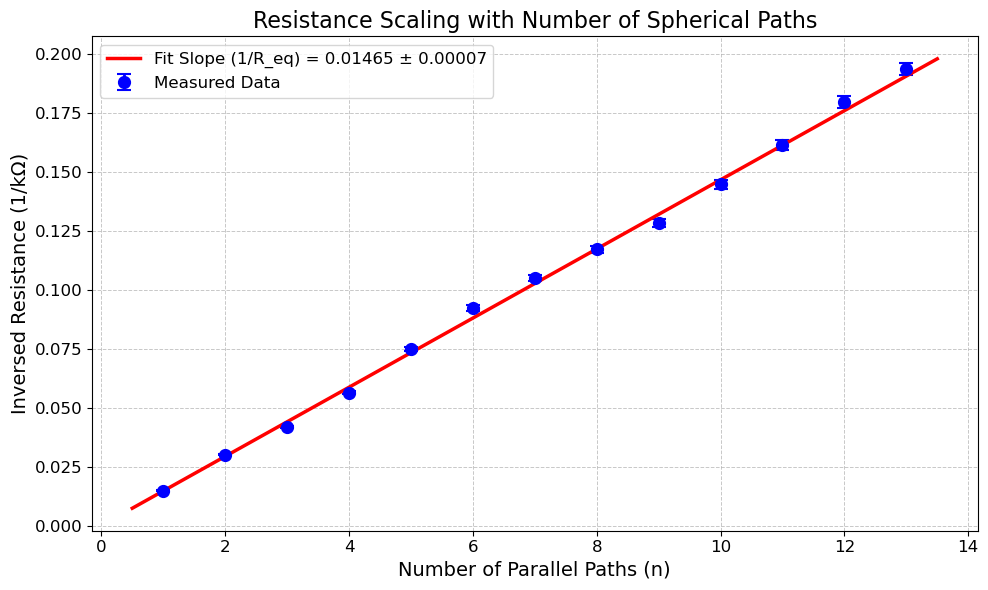

Slope (A): 0.01465 ± 0.00007 (1/kΩ)
Intercept (B): 0.00008 ± 0.00021 (1/kΩ)


In [222]:
# Data
x = data["Paths"]
y = data["invResistance (1/kΩ)"]
yerr = data["dinvResistance (1/kΩ)"]

# Define linear model
def my_linear_model(x, A, B):
    return A * x + B

# Perform the curve fit
fit_param, fit_cov = opt.curve_fit(my_linear_model, x, y, sigma=yerr, absolute_sigma=True)
fitA, fitB = fit_param
fitdA = np.sqrt(fit_cov[0, 0])
fitdB = np.sqrt(fit_cov[1, 1])

# Generate smooth x values for fit line
x_fit = np.linspace(min(x) - 0.5, max(x) + 0.5, 500)

# Set figure size for clarity
plt.figure(figsize=(10, 6))

# Plot error bars
plt.errorbar(
    x, y, yerr=yerr, fmt='o', markersize=8, capsize=5,
    elinewidth=2, markeredgewidth=1.5, label="Measured Data", c='b'
)

# Plot fitted curve
plt.plot(
    x_fit, my_linear_model(x_fit, fitA, fitB),
    '-', linewidth=2.5, label=f"Fit Slope (1/R_eq) = {fitA:.5f} ± {fitdA:.5f}", c='r'
) 

# Labels and Title
plt.xlabel("Number of Parallel Paths (n)", fontsize=14)
plt.ylabel("Inversed Resistance (1/kΩ)", fontsize=14)
plt.title("Resistance Scaling with Number of Spherical Paths", fontsize=16)

# Customize ticks
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

# Gridlines
plt.grid(True, which="both", linestyle="--", linewidth=0.7, alpha=0.7)

# Add a nice legend
plt.legend(fontsize=12, frameon=True, loc="best")

# Improve plot layout
plt.tight_layout()

# Show the plot
plt.show()

# Print fit parameters nicely
print(f"Slope (A): {fitA:.5f} ± {fitdA:.5f} (1/kΩ)")
print(f"Intercept (B): {fitB:.5f} ± {fitdB:.5f} (1/kΩ)")

Here, we again verify that the data follows the expected linear relationship, with the line going through (or touching) the uncertainty ranges for all 12 points with no major outliers. Furthermore, we note that the expected value of $ b $ holds up, since $ 0.00008 \pm 0.0002 $ includes the expected value of $ b = 0 $. Thus, we can conclude that the linearization holds up in this direction, too, and that the previous line-up wasn't some kind of fluke.

Beyond just verifying the aforementioned parallel circuit reciprocal connection, we can also assess if the resistance holds true here. As mentioned earlier, $ m = \frac{1}{R} $, and we received a value of $ m = 0.01465 \pm 0.00007 $. Changing things to fraction form, we get $ m = \frac{293}{20000} \pm 0.00007 $ or, to simplify further, $ m = \frac{1}{68.25} \pm 0.00007 $

In order to find the error associated with $ R $, we can propagate the error of $ m $ as follows:

$ δR = \frac{δm}{m^2} $

$ δR = \frac{0.00007}{0.01465^2} $

$ δR = \frac{0.00007}{0.00021} $

$ δR = 0.333 $

Thus, we conclude that $ R = 68.3 \pm 0.3 kΩ $, effectively identical to the $ 68.3 \pm 0.5 kΩ $ value we obtained from the other direction. Combining the errors into one data point would then yield $ \frac{1}{\sqrt{\frac{1}{0.3^2} + \frac{1}{0.5^2}}} $, which gets a final result of $ δR = 0.257 $. Thus, we conclude more definitively that $ R = 68.3 \pm 0.3 kΩ $

We also get the rewritten equation of $ \frac{1}{R_{eq}} = \frac{n}{68.3} + 0.00008 $

## Conclusion:
To conclude, we were able to use our ball experiment to verify that the resistance of a parallel series does indeed follow the known relationship $ \frac{1}{R_{eq}} = \frac{1}{R_1} + \frac{1}{R_2} + ... + \frac{1}{R_n} $, with tests setting $ y = R_{eq} $ and $ y = \frac{1}{R_{eq}} $ both confirming as much, and with no unusual properties noted in the graphs (linear, lack of outliers, intercept compatible with 0)

Furthermore, we were also able to use this experiment to conclude that the resistance across the defined distance (length = $ 14 \pm 0.2 cm $, width = $ 1.4 \pm 0.2 cm $) was a total $ 68.3 \pm 0.3 kΩ $

### Dominant Source of Uncertainty:
The dominant source of uncertainty through this experiment has been in the measurement of the resistance values. There is no question on the number of paths, so there is no uncertainty attached - all uncertainty derives from the DMM readings. If we were to create a more accurate experiment next time, we would want to get a more accurate DMM to reduce the uncertainty as much as possible

### Application to Physics:
This experiment is applicable to physics more generally since this experiment demonstrated one of the most fundamental principles of circuits - that the resistance of a parallel series has a reciprocal sum relationship with the component resistances. Furthermore, since all components were identical, we could then use this relationship to find individual resistances, which is rather useful


Since:

$$
R = \frac{1}{m}
$$
$$
\delta R = \left| \frac{dR}{dm} \right| \delta m
$$

$$
\frac{dR}{dm} = -\frac{1}{m^2} \quad \text{thus} \quad
\delta R = \frac{\delta m}{m^2}
$$
Thus:

$$
\delta R = \frac{\delta m}{m^2}
$$
